## 1. Importing Libs

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score, 
    recall_score, 
    ConfusionMatrixDisplay, 
    classification_report
    )
from sklearn.ensemble import RandomForestClassifier

## 2. Data Loading & Cleaning

In [2]:
titanic = pd.read_csv(r'C:\Users\ahmed\Desktop\Titanic-Dataset.csv')
titanic = titanic.dropna(subset = ['Embarked'])
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].mean())
titanic['Cabin'] = titanic['Cabin'].fillna('Unknown')
titanic['Deck'] = titanic['Cabin'].str[0]
titanic = titanic.drop('Cabin', axis=1)
titanic['TicketCount'] = titanic.groupby('Ticket')['Ticket'].transform('count')
titanic = titanic.drop(['Name', 'Ticket', 'PassengerId'], axis = 1)
print(titanic.shape)
print(titanic.isna().sum())

(889, 10)
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
Deck           0
TicketCount    0
dtype: int64


## 3. Feature Encoding

In [3]:
dummies = pd.get_dummies(titanic[['Sex','Embarked','Deck','TicketCount']], drop_first = True)
titanic = pd.concat([titanic, dummies], axis=1)
titanic = titanic.drop(['Sex','Embarked','Deck','TicketCount'], axis = 1)
titanic.head()
titanic.dtypes

Survived        int64
Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Sex_male         bool
Embarked_Q       bool
Embarked_S       bool
Deck_B           bool
Deck_C           bool
Deck_D           bool
Deck_E           bool
Deck_F           bool
Deck_G           bool
Deck_T           bool
Deck_U           bool
dtype: object

## 4. train_test_split

In [4]:
x = titanic.drop('Survived', axis = 1)
y = titanic['Survived']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state= 42)

## 5. Models

### 1. KNN (Tuned)

In [5]:
params_knn= {'n_neighbors': np.arange(1, 20)}

knn = KNeighborsClassifier()
kf = KFold(n_splits= 5, random_state=42 , shuffle= True)

knn_grid = GridSearchCV(knn, params_knn, cv = kf)
knn_grid.fit(x_train, y_train)
y_pred_knn = knn_grid.predict(x_test)

best_param_knn = knn_grid.best_params_['n_neighbors']
print(knn_grid.best_params_)
print(knn_grid.best_score_)


{'n_neighbors': 16}
0.7172461341475425


### 2. Logistic Regression

In [6]:
logreg = LogisticRegression(max_iter= 1000)
logreg.fit(x_train, y_train)
y_pred_logreg = logreg.predict(x_test)

### 3. Random Forest (Tuned)

In [7]:
params_rf = {'n_estimators': [50, 100, 200, 300]}

rf = RandomForestClassifier(random_state= 42)
rf_grid = GridSearchCV(rf, param_grid= params_rf, cv= kf)
rf_grid.fit(x_train, y_train)
y_pred_rf = rf_grid.predict(x_test)

best_param_rf = rf_grid.best_params_['n_estimators']
print(rf_grid.best_params_)
print(rf_grid.best_score_)

{'n_estimators': 50}
0.8396631537476609


### 4. XGBoost (Tuned)

In [8]:
params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7]
}
xgb_model = xgb.XGBClassifier(objective= 'binary:logistic')
xgb_grid = GridSearchCV(xgb_model, param_grid= params, cv= kf, scoring= 'accuracy')
xgb_grid.fit(x_train, y_train)

print(xgb_grid.best_params_)
print(xgb_grid.best_score_)
xgb_pred = xgb_grid.predict(x_test)
print(xgb_grid.score(x_test, y_test))

{'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 300}
0.8439279030828326
0.8089887640449438


## 6. Pipeline KNN

In [9]:
imputer = SimpleImputer()
scaler = StandardScaler()
knn = KNeighborsClassifier(n_neighbors= best_param_knn)

steps = [('imp_mean', imputer),
         ('scaler', scaler),
         ('knn', knn)]

knn_pipeline = Pipeline(steps)
knn_pipeline.fit(x_train, y_train)
y_pred_pipeline = knn_pipeline.predict(x_test)
print(f'Pipeline accuracy: {knn_pipeline.score(x_test, y_test)}')

Pipeline accuracy: 0.797752808988764


## 7. Model Results

| Model                 | Accuracy | F1    | Precision | Recall |
|-----------------------|----------|-------|-----------|--------|
| XGBoost (tuned)       | 80.9%    | 0.750 | 0.761     | 0.739  |
| Pipeline KNN          | 78.7%    | 0.732 | 0.712     | 0.753  |
| Logistic Regression   | 78.1%    | 0.735 | 0.692     | 0.783  |
| Random Forest (tuned) | 74.7%    | 0.694 | 0.654     | 0.739  |
| KNN (k=16, tuned)     | 70.0%    | 0.559 | 0.673     | 0.478  |

**Best model: XGBoost (tuned) — 80.9% accuracy**

Key observations:
- XGBoost is now the clear winner with more training data (889 vs 712 rows)
- Keeping Age rows via fillna instead of dropna gave the model more data to learn from
- More complex models (XGBoost, RF) benefit more from larger datasets than simpler ones
- Pipeline KNN accuracy is missing F1/precision/recall — add classification_report there

In [10]:
print('LogisticRegression:')
print(f'Accuracy: {accuracy_score(y_test, y_pred_logreg)}')
print(f'F1: {f1_score(y_test, y_pred_logreg)}')
print(f'Precision: {precision_score(y_test, y_pred_logreg)}')
print(f'Recall: {recall_score(y_test, y_pred_logreg)}')
print('------------------------------')
print('KNN:')
print(f'Accuracy: {accuracy_score(y_test, y_pred_knn)}')
print(f'F1: {f1_score(y_test, y_pred_knn)}')
print(f'Precision: {precision_score(y_test, y_pred_knn)}')
print(f'Recall: {recall_score(y_test, y_pred_knn)}')
print('------------------------------')
print('RF:')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf)}')
print(f'F1: {f1_score(y_test, y_pred_rf)}')
print(f'Precision: {precision_score(y_test, y_pred_rf)}')
print(f'Recall: {recall_score(y_test, y_pred_rf)}')
print('------------------------------')
print('XGBoost')
print(f'Accuracy: {accuracy_score(y_test, xgb_pred)}')
print(f'F1: {f1_score(y_test, xgb_pred)}')
print(f'Precision: {precision_score(y_test, xgb_pred)}')
print(f'Recall: {recall_score(y_test, xgb_pred)}')
print('------------------------------')
print('KNN Pipeline')
print(f'Accuracy: {accuracy_score(y_test, y_pred_pipeline)}')
print(f'F1: {f1_score(y_test, y_pred_pipeline)}')
print(f'Precision: {precision_score(y_test, y_pred_pipeline)}')
print(f'Recall: {recall_score(y_test, y_pred_pipeline)}')

LogisticRegression:
Accuracy: 0.7921348314606742
F1: 0.7448275862068966
Precision: 0.7105263157894737
Recall: 0.782608695652174
------------------------------
KNN:
Accuracy: 0.7078651685393258
F1: 0.559322033898305
Precision: 0.673469387755102
Recall: 0.4782608695652174
------------------------------
RF:
Accuracy: 0.7752808988764045
F1: 0.7222222222222222
Precision: 0.6933333333333334
Recall: 0.7536231884057971
------------------------------
XGBoost
Accuracy: 0.8089887640449438
F1: 0.75
Precision: 0.7611940298507462
Recall: 0.7391304347826086
------------------------------
KNN Pipeline
Accuracy: 0.797752808988764
F1: 0.7391304347826086
Precision: 0.7391304347826086
Recall: 0.7391304347826086


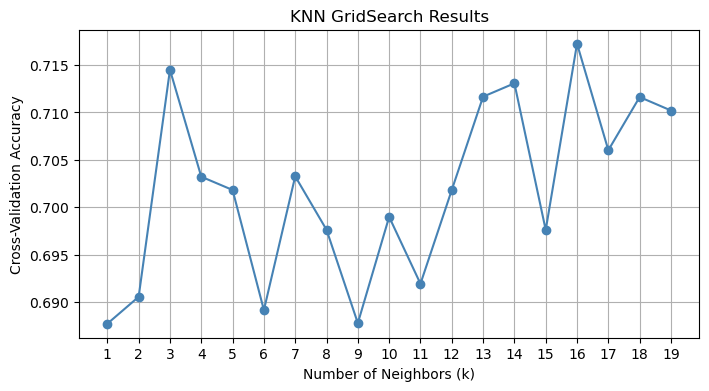

In [11]:
results = knn_grid.cv_results_
plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, 20), results['mean_test_score'], marker='o', color='steelblue')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Cross-Validation Accuracy')
plt.title('KNN GridSearch Results')
plt.xticks(np.arange(1, 20))
plt.grid(True)
plt.show()

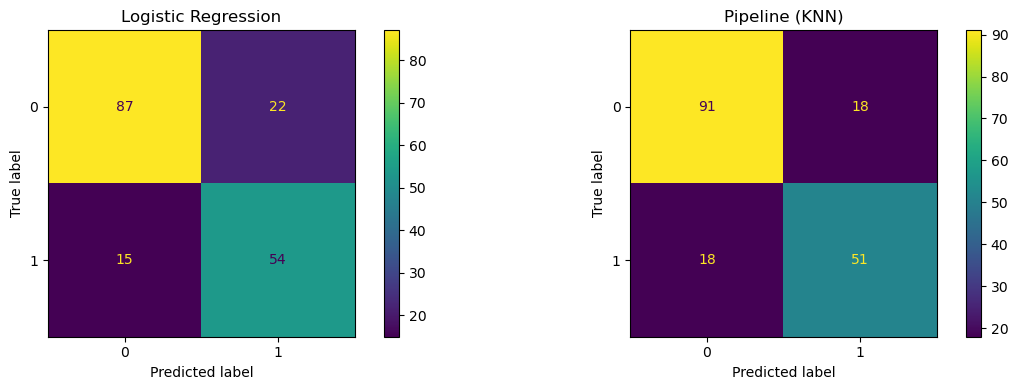

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_logreg, ax=axes[0])
axes[0].set_title('Logistic Regression')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_pipeline, ax=axes[1])
axes[1].set_title('Pipeline (KNN)')
plt.tight_layout()
plt.show()

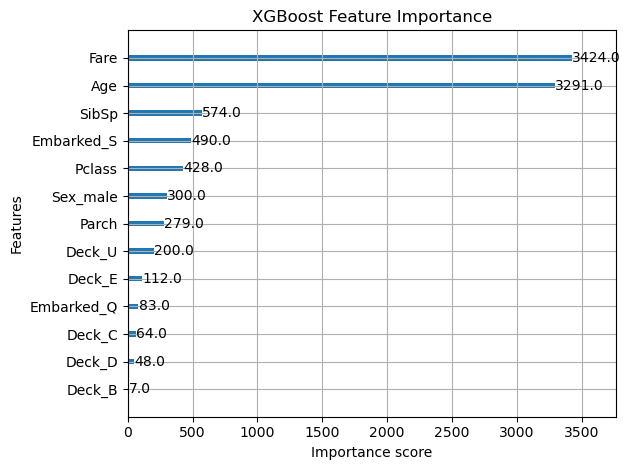

In [13]:
xgb.plot_importance(xgb_grid.best_estimator_)
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

In [14]:
titanic.to_csv('titanic_clean.csv', index=False)